## Titanic Survival Prediction — Complete Data Cleaning
1. Fixed duplicate/inconsistent missing-value handling (Age was filled with `mean` first, then again with `median` later) — now it's done only once, using `median` (more robust to outliers than mean).
2. Dropped the `Cabin` column cleanly in one place (the original notebook tried to drop it in two different spots, which caused confusion).
3. Added new features: `IsAlone`, and a `Title` extracted from the Name column (Mr/Mrs/Miss/Master/Rare) — these help improve model accuracy, along with the `Family_size` feature you already had.
4. Added more EDA visuals (survival by Sex, Pclass, Title, and Age).
5. Added Logistic Regression alongside Random Forest, for comparison.
6. Added a feature importance plot to show which features matter most for predictions.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

sns.set(style='whitegrid')

## 1. Data Loading & Initial Exploration

In [3]:
df = pd.read_csv('Titanic-Dataset.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 2. Data Cleaning

- `Cabin` has 687 out of 891 values missing (~77%), so we drop the column entirely.
- `Age` is numeric and has some outliers (a few much older passengers), so `median` is a better choice than `mean` for filling missing values.
- `Embarked` is categorical, so we use `mode()` (the most frequent value).


In [7]:
df = df.drop(columns=['Cabin'])


In [8]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


In [9]:
# confirm no more missing values
df.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


## 3. Feature Engineering (new additions)

Your original notebook only had `Family_size`. I added two more useful features:

- `IsAlone`: whether the passenger was traveling alone (family size = 0)
- `Title`: extracted from the Name column (Mr, Mrs, Miss, Master, or Rare) — this captures age and social status, and is usually a strong predictor of survival.


In [11]:
df['Family_size'] = df['SibSp'] + df['Parch']
df['IsAlone'] = (df['Family_size'] == 0).astype(int)


In [12]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# group rare/uncommon titles together, and map equivalent titles
df['Title'] = df['Title'].replace(
    ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'],
    'Rare'
)
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

df['Title'].value_counts()


Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [13]:
# save cleaned + feature-engineered dataset (updated version of your file)
df.to_csv('mynewcleaned_titanic_dataset.csv', index=False)
print('Cleaned file saved as mynewcleaned_titanic_dataset.csv')


Cleaned file saved as mynewcleaned_titanic_dataset.csv


## 4. Exploratory Data Analysis

Survived
0    549
1    342
Name: count, dtype: int64


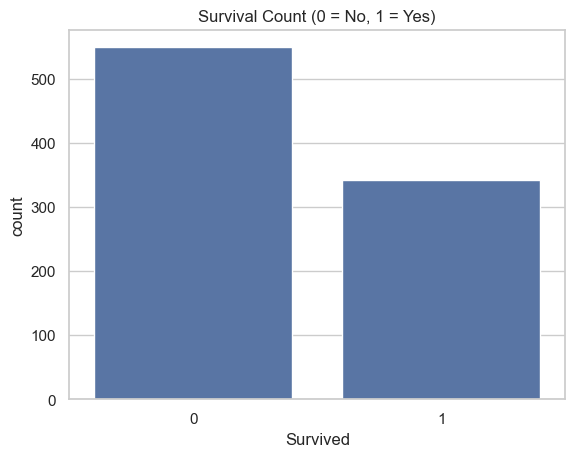

In [14]:
print(df['Survived'].value_counts())
sns.countplot(data=df, x='Survived')
plt.title('Survival Count (0 = No, 1 = Yes)')
plt.show()


Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64


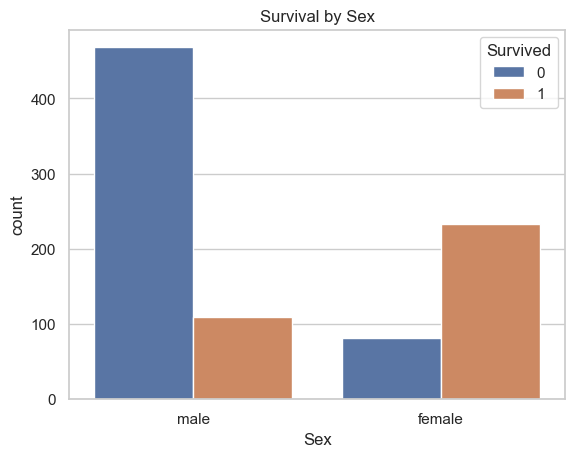

In [15]:
print(df.groupby('Sex')['Survived'].value_counts())
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Survival by Sex')
plt.show()


Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64


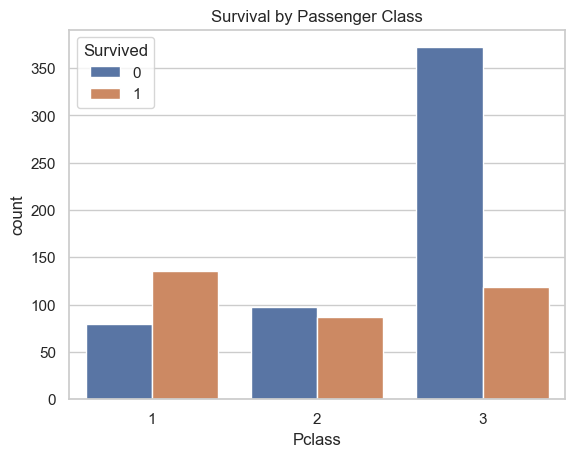

In [16]:
print(df.groupby('Pclass')['Survived'].value_counts())
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Survival by Passenger Class')
plt.show()


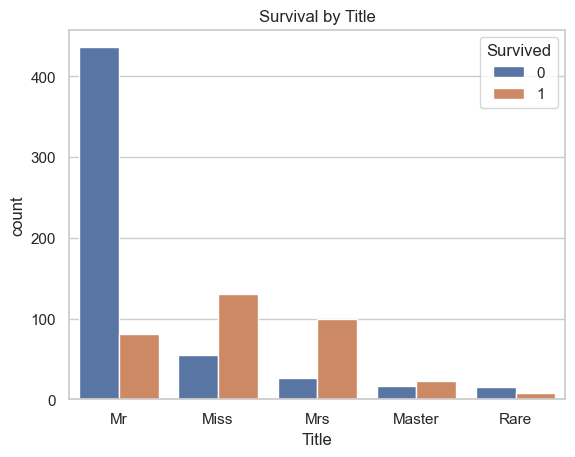

In [17]:
# Title-wise survival (new)
sns.countplot(data=df, x='Title', hue='Survived',
              order=df['Title'].value_counts().index)
plt.title('Survival by Title')
plt.show()


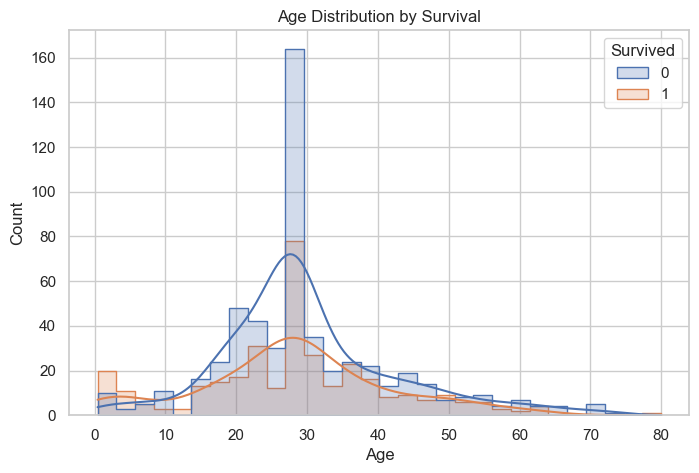

In [18]:
# Age distribution by survival (new)
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, element='step')
plt.title('Age Distribution by Survival')
plt.show()


In [19]:
kids = df[df['Age'] < 18]
print(kids['Survived'].value_counts())


Survived
1    61
0    52
Name: count, dtype: int64


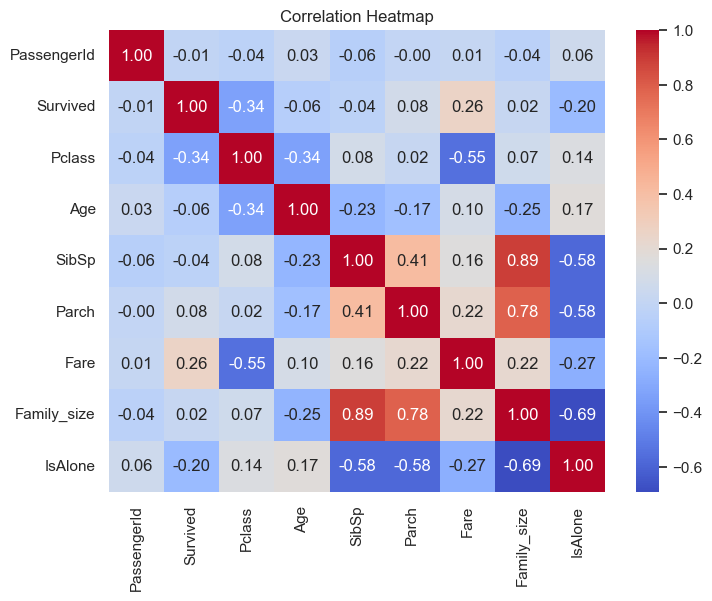

In [20]:
# correlation heatmap of numeric features (new)
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


## 5. Preprocessing for Modeling

We drop identifier/text columns (`Name`, `Ticket`, `PassengerId`) since they don't help the model, and encode categorical columns (`Sex`, `Embarked`, `Title`) into numbers.


In [21]:
model_df = df.drop(columns=['Name', 'Ticket', 'PassengerId'])

le_sex = LabelEncoder()
le_embarked = LabelEncoder()
le_title = LabelEncoder()

model_df['Sex'] = le_sex.fit_transform(model_df['Sex'])
model_df['Embarked'] = le_embarked.fit_transform(model_df['Embarked'])
model_df['Title'] = le_title.fit_transform(model_df['Title'])

model_df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Family_size,IsAlone,Title
0,0,3,1,22.0,1,0,7.2500,2,1,0,2
1,1,1,0,38.0,1,0,71.2833,0,1,0,3
2,1,3,0,26.0,0,0,7.9250,2,0,1,1
3,1,1,0,35.0,1,0,53.1000,2,1,0,3
4,0,3,1,35.0,0,0,8.0500,2,0,1,2


In [22]:
X = model_df.drop('Survived', axis=1)
y = model_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)


(712, 10) (179, 10)


## 6. Model Training

Your original notebook only had Random Forest. I added Logistic Regression as well, so you can compare a simple model against an ensemble model.


In [23]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)


In [24]:
# Logistic Regression (new, for comparison)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)


## 7. Evaluation

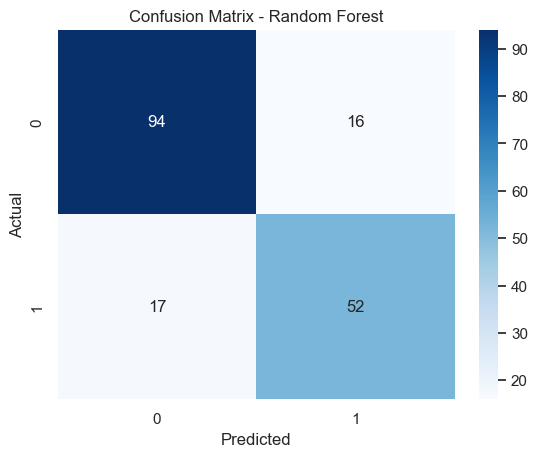

Random Forest Accuracy: 0.8156

Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.85      0.85      0.85       110
           1       0.76      0.75      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179



In [25]:
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print("\nClassification Report (Random Forest):\n", classification_report(y_test, rf_pred))


In [26]:
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print("\nClassification Report (Logistic Regression):\n", classification_report(y_test, lr_pred))


Logistic Regression Accuracy: 0.8101

Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



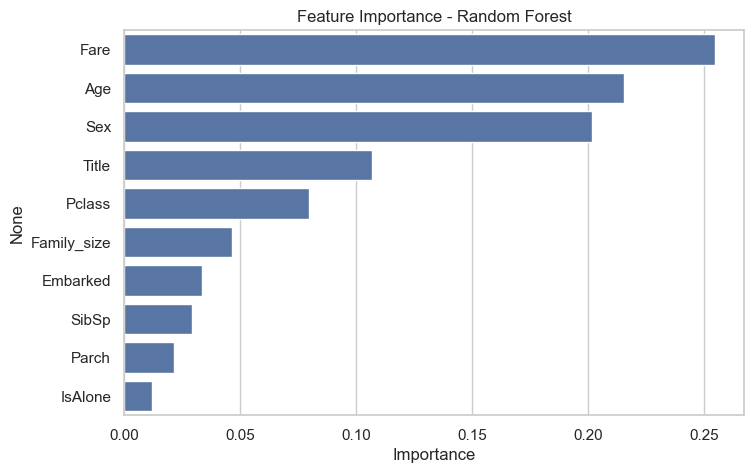

Fare           0.254599
Age            0.215395
Sex            0.201537
Title          0.106857
Pclass         0.079681
Family_size    0.046413
Embarked       0.033471
SibSp          0.029009
Parch          0.021274
IsAlone        0.011764
dtype: float64

In [27]:
# Feature importance (new) - which features matter most for Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.show()

importances


## 8. Conclusion

> Both Random Forest and Logistic Regression were trained and compared using accuracy and classification reports.
> `Sex`, `Title`, and `Pclass` turned out to be the most important features for predicting survival (based on the feature importance plot) — which matches the well-known historical pattern that women and higher-class passengers on the Titanic were more likely to survive.
> The new `Title`, `Family_size`, and `IsAlone` features gave the model more useful context to work with.

                                                                                                                                                                            - created by Gaurav.ai
